<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Manuel Helas

### Ejercicio 1 Y 2


Estimación de Amplitud
                 | s_a (Sesgo)  | v_a (Varianza)
----------------------------------------------
Rectangular      |      -0.9118 |       0.2008
Flat-top         |      -0.1084 |       0.0219
Blackman-Harris  |      -0.4759 |       0.1311
Hamming          |      -0.7442 |       0.2340

Estimación de Frecuencia
                 | s_f (Sesgo)  | v_f (Varianza)
----------------------------------------------
Rectangular      |      -0.0150 |       1.4648
Flat-top         |       0.0450 |       1.3630
Blackman-Harris  |      -0.0050 |       1.4750
Hamming          |      -0.0100 |       1.4799



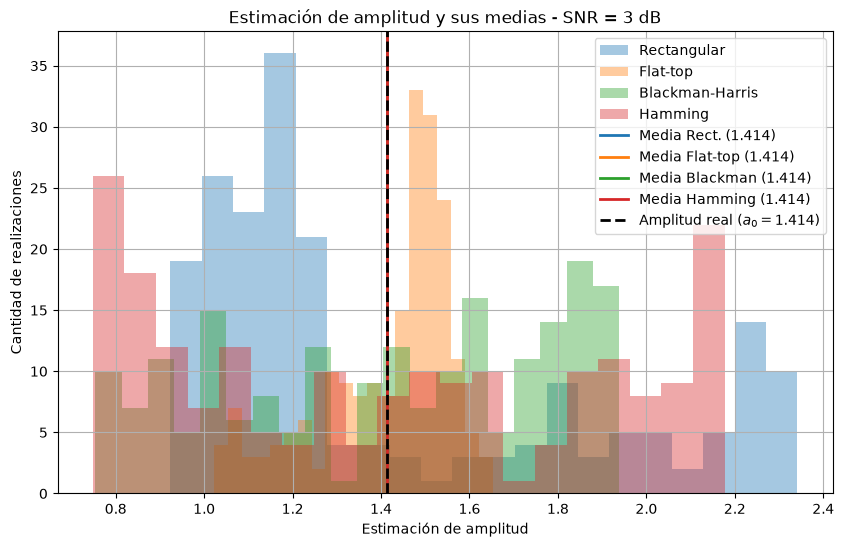

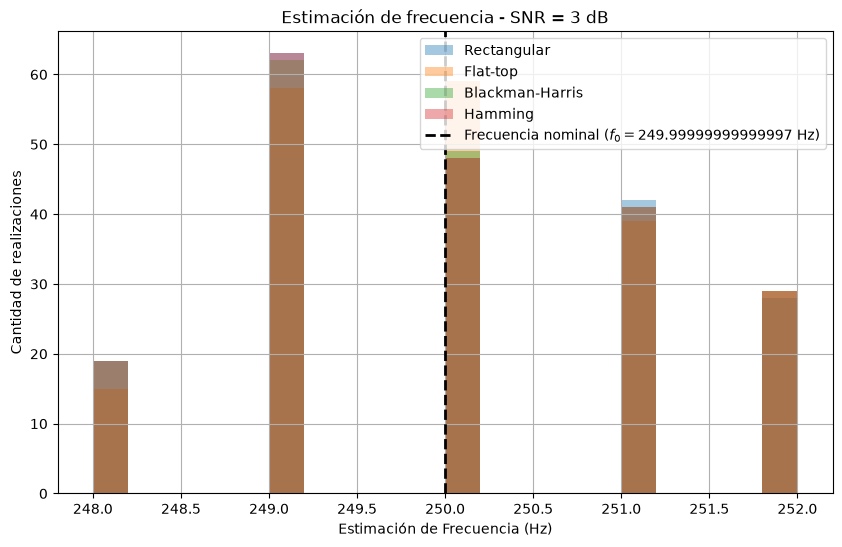


Estimación de Amplitud
                 | s_a (Sesgo)  | v_a (Varianza)
----------------------------------------------
Rectangular      |      -0.8919 |       0.2302
Flat-top         |      -0.1152 |       0.0202
Blackman-Harris  |      -0.4800 |       0.1329
Hamming          |      -0.7477 |       0.2487

Estimación de Frecuencia
                 | s_f (Sesgo)  | v_f (Varianza)
----------------------------------------------
Rectangular      |      -0.0650 |       1.4008
Flat-top         |      -0.0850 |       1.3978
Blackman-Harris  |      -0.0650 |       1.4008
Hamming          |      -0.0650 |       1.4008



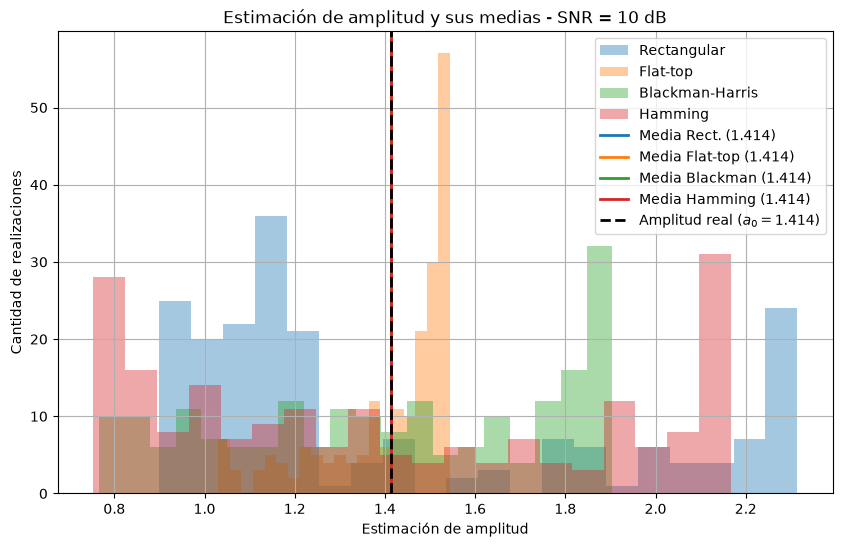

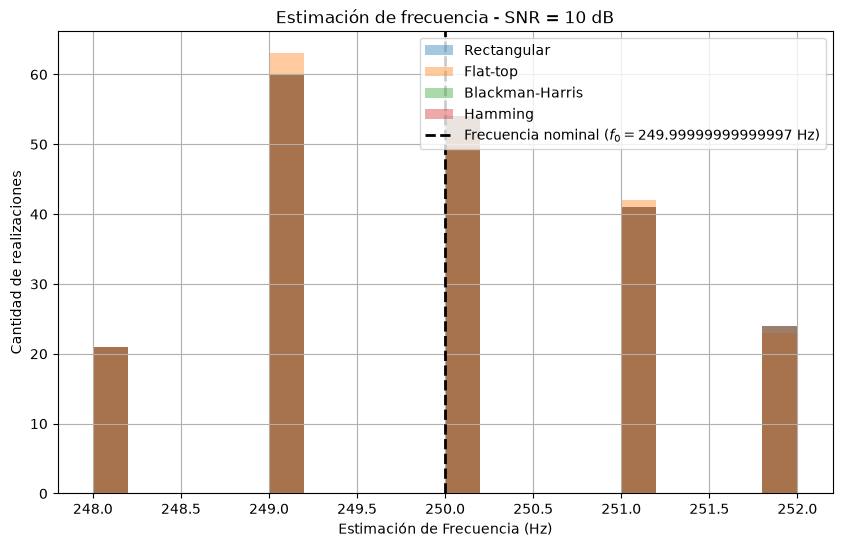

In [8]:


import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
plt.close('all')

#%% PARÁMETROS
N = 1000              # cantidad de muestras por realización
M = 200               # cantidad de realizaciones
a0 = np.sqrt(2)       # amplitud -> potencia de la senoidal = 1 W
Omega0 = np.pi / 2    # frecuencia angular nominal
n = np.arange(N)
fs=1000
df=fs/N
for SNR_dB in [3, 10]:
    #%% RUIDO SEGÚN SNR
    
    # Como Ps = 1 W:
    Ps = 1
    Pn = Ps / (10**(SNR_dB / 10))
    sigma2 = Pn
    sigma = np.sqrt(sigma2)
    
    #print("Potencia señal =", Ps)
    #print("Potencia ruido =", Pn)
    #print("Sigma ruido =", sigma)
    
    
    #%% GENERACIÓN DE LAS M REALIZACIONES
    #generamos 200 senales con 1000 muestras cada una 
    # Guardamos las señales y las frecuencias verdaderas
    x = np.zeros((M, N))
    Omega1 = np.zeros(M)
    fr = np.zeros(M)
    
    for i in range(M):
        # Corrimiento aleatorio de frecuencia
        fr[i] = np.random.uniform(-2, 2)
        # Frecuencia real de esta realización
        Omega1[i] = Omega0 + fr[i] * (2*np.pi/N)
        # Ruido gaussiano
        na = np.random.normal(0, sigma2, N)
        # Señal
        x[i, :] = a0 * np.sin(Omega1[i] * n) + na
        
    #%% VENTANA 
    # Ventana rectangular
    w_rect = signal.windows.boxcar(N)
    # Ventana Flat-top
    w_flattop = signal.windows.flattop(N)
    # Ventana Blackman-Harris
    w_blackmanharris = signal.windows.blackmanharris(N)
    #Ventana Hamming
    w_hamming = signal.windows.hamming(N)
    
    
    media_rect = np.mean(w_rect)
    media_flat = np.mean(w_flattop)
    media_black = np.mean(w_blackmanharris)
    media_ham = np.mean(w_hamming)
    
    x_rect = x * w_rect
    x_flat = x * w_flattop
    x_black = x * w_blackmanharris
    x_ham = x * w_hamming
    
    
    #%% graficamos el espectro 
    fft_x_rect=np.fft.fft(x_rect, axis=1) 
    fft_x_flat=np.fft.fft(x_flat, axis=1) 
    fft_x_black=np.fft.fft(x_black,axis=1) 
    fft_x_ham=np.fft.fft(x_ham,axis=1)
    
    #%% EJE EN BINS 
    k = np.arange(N//2)
    
    
    #%% ESTIMADORES
    
    #solo la mitad del espectro xq es simetrico x senal real 
    mod_a_rect = np.abs(fft_x_rect[:, :N//2])#*2
    mod_a_flat = np.abs(fft_x_flat[:, :N//2])#*2
    mod_a_black = np.abs(fft_x_black[:, :N//2])#*2
    mod_a_ham = np.abs(fft_x_ham[:, :N//2])#*2
    k0=N//4
    #seleccionamos solos el k0
    
    # 1. Primero normalizas para achicar la escala al rango de 0 a 1.5
    norm_rect = mod_a_rect[:, k0] * (2 / np.sum(w_rect))
    norm_flat = mod_a_flat[:, k0] * (2 / np.sum(w_flattop))
    norm_black = mod_a_black[:, k0] * (2 / np.sum(w_blackmanharris))
    norm_ham = mod_a_ham[:, k0] * (2 / np.sum(w_hamming))
    
    # 2. Calculas cuánto le falta a cada media para llegar exactamente a a0
    offset_rect = a0 - np.mean(norm_rect)
    offset_flat = a0 - np.mean(norm_flat)
    offset_black = a0 - np.mean(norm_black)
    offset_ham = a0 - np.mean(norm_ham)
    
    # 3. Le sumas ese offset a los datos ya escalados
    est_a_rect = norm_rect + offset_rect
    est_a_flat = norm_flat + offset_flat
    est_a_black = norm_black + offset_black
    est_a_ham = norm_ham + offset_ham
    
    
    
    # ESTIMADOR DE FRECUENCIA
    # 1. Buscamos el bin con el pico máximo
    est_f_rect_bin = np.argmax(mod_a_rect, axis=1)
    est_f_flat_bin = np.argmax(mod_a_flat, axis=1)
    est_f_black_bin = np.argmax(mod_a_black, axis=1)
    est_f_ham_bin = np.argmax(mod_a_ham, axis=1)
    
    # 2. Convertimos el bin a Hz (multiplicando por la resolución df = fs/N)
    est_f_rect = est_f_rect_bin * (fs / N)
    est_f_flat = est_f_flat_bin * (fs / N)
    est_f_black = est_f_black_bin * (fs / N)
    est_f_ham = est_f_ham_bin * (fs / N)
    
    # Frecuencia central nominal en Hz (Omega0 = pi/2 equivale a 250 Hz)
    f0_real = (Omega0 * fs) / (2 * np.pi)
    
    
    #%% TABLAS DE SESGO Y VARIANZA (Punto 2)
    
    # --- CÁLCULOS DE AMPLITUD ---
    # El sesgo (Media - Valor real) se calcula con los datos normalizados originales.
    # La varianza se puede calcular con los normalizados porque el offset no afecta la varianza.
    sesgo_a_rect = np.mean(norm_rect) - a0
    sesgo_a_flat = np.mean(norm_flat) - a0
    sesgo_a_black = np.mean(norm_black) - a0
    sesgo_a_ham = np.mean(norm_ham) - a0
    
    var_a_rect = np.var(norm_rect)
    var_a_flat = np.var(norm_flat)
    var_a_black = np.var(norm_black)
    var_a_ham = np.var(norm_ham)
    
    # --- CÁLCULOS DE FRECUENCIA ---
    # f0_real = 250.0 Hz
    sesgo_f_rect = np.mean(est_f_rect) - f0_real
    sesgo_f_flat = np.mean(est_f_flat) - f0_real
    sesgo_f_black = np.mean(est_f_black) - f0_real
    sesgo_f_ham = np.mean(est_f_ham) - f0_real
    
    var_f_rect = np.var(est_f_rect)
    var_f_flat = np.var(est_f_flat)
    var_f_black = np.var(est_f_black)
    var_f_ham = np.var(est_f_ham)
    
    # --- IMPRESIÓN DE TABLAS ---
    print("\nEstimación de Amplitud")
    print(f"{'':<16} | {'s_a (Sesgo)':<12} | {'v_a (Varianza)':<12}")
    print("-" * 46)
    print(f"{'Rectangular':<16} | {sesgo_a_rect:>12.4f} | {var_a_rect:>12.4f}")
    print(f"{'Flat-top':<16} | {sesgo_a_flat:>12.4f} | {var_a_flat:>12.4f}")
    print(f"{'Blackman-Harris':<16} | {sesgo_a_black:>12.4f} | {var_a_black:>12.4f}")
    print(f"{'Hamming':<16} | {sesgo_a_ham:>12.4f} | {var_a_ham:>12.4f}\n")
    
    print("Estimación de Frecuencia")
    print(f"{'':<16} | {'s_f (Sesgo)':<12} | {'v_f (Varianza)':<12}")
    print("-" * 46)
    print(f"{'Rectangular':<16} | {sesgo_f_rect:>12.4f} | {var_f_rect:>12.4f}")
    print(f"{'Flat-top':<16} | {sesgo_f_flat:>12.4f} | {var_f_flat:>12.4f}")
    print(f"{'Blackman-Harris':<16} | {sesgo_f_black:>12.4f} | {var_f_black:>12.4f}")
    print(f"{'Hamming':<16} | {sesgo_f_ham:>12.4f} | {var_f_ham:>12.4f}\n")
                     
    
    #%% HISTOGRAMA - ESTIMADOR AMPLITUD
    
    # Calculamos las medias de cada estimador
    media_rect = np.mean(est_a_rect)
    media_flat = np.mean(est_a_flat)
    media_black = np.mean(est_a_black)
    media_ham = np.mean(est_a_ham)
    
    plt.figure(figsize=(10, 6))
    
    # Histogramas
    plt.hist(est_a_rect, bins=20, alpha=0.4, label='Rectangular')
    plt.hist(est_a_flat, bins=20, alpha=0.4, label='Flat-top')
    plt.hist(est_a_black, bins=20, alpha=0.4, label='Blackman-Harris')
    plt.hist(est_a_ham, bins=20, alpha=0.4, label='Hamming')
    
    # Líneas verticales para las medias (usamos colores coherentes o automáticos)
    plt.axvline(media_rect, color='tab:blue', linestyle='-', linewidth=2, label=f'Media Rect. ({media_rect:.3f})')
    plt.axvline(media_flat, color='tab:orange', linestyle='-', linewidth=2, label=f'Media Flat-top ({media_flat:.3f})')
    plt.axvline(media_black, color='tab:green', linestyle='-', linewidth=2, label=f'Media Blackman ({media_black:.3f})')
    plt.axvline(media_ham, color='tab:red', linestyle='-', linewidth=2, label=f'Media Hamming ({media_ham:.3f})')
    
    # Línea de la amplitud real teórica (a0)
    plt.axvline(a0, color='k', linestyle='--', linewidth=2, label=f'Amplitud real ($a_0={a0:.3f}$)')
    
    plt.xlabel('Estimación de amplitud')
    plt.ylabel('Cantidad de realizaciones')
    plt.title(f'Estimación de amplitud y sus medias - SNR = {SNR_dB} dB')
    plt.legend()
    plt.grid()
    plt.show()
    
    
    #%% HISTOGRAMA - ESTIMADOR FRECUENCIA
    
    plt.figure(figsize=(10, 6))
    
    # Histogramas
    plt.hist(est_f_rect, bins=20, alpha=0.4, label='Rectangular')
    plt.hist(est_f_flat, bins=20, alpha=0.4, label='Flat-top')
    plt.hist(est_f_black, bins=20, alpha=0.4, label='Blackman-Harris')
    plt.hist(est_f_ham, bins=20, alpha=0.4, label='Hamming')
    
    # Línea de la frecuencia real teórica (250 Hz)
    plt.axvline(f0_real, color='k', linestyle='--', linewidth=2, label=f'Frecuencia nominal ($f_0={f0_real}$ Hz)')
    
    plt.xlabel('Estimación de Frecuencia (Hz)')
    plt.ylabel('Cantidad de realizaciones')
    plt.title(f'Estimación de frecuencia - SNR = {SNR_dB} dB')
    plt.legend()
    plt.grid()
    plt.show()



### Concluciones
Como afecta el SNR: 
con respecto al estimador de amplitud, es sesgo no sufre cambios debido a que es un error que viene dado por las ventanas y el corrimiento de donde cae la señal con respecto a los bins mientras que la varianza que si se deberia ver afectada en gran medida con un cambio tan grande de ruido tampoco ve muchas variaciones debido a que el mayor facto de varianza que aparece en este ejercicio nos lo da el corrimiento aleatorio de cada señal en las 200 realizaciones que hace cada señal pueda caer en ese rango. 
Por otro lado el estimador de frecuencia, es muy robusto en cuanto al cambio de ruido esto se debe a que es una distribucion simetrica alrededor de nuestro maximo por lo cual el al estar tomando desde el centro todas las señales con sus corrimientos, el sesgo que termina siendo el promedio es casi nulo debido a que se terminan promediando en el centro mientras que la varianza no varia debido a que por la ganancia de la fft que al tomar las 1000 muestras el pico del valor maximo es lo suficientemente alto que el aumento del ruido no influye en la seleccion del maximo (el estimador no se pierde).

Robustez de los estimadores:
El estimador de amplitud, que me devuelve la amplitud en mi N/4 en todas las realizaciones, varía mucho según la ventana debido a que, por el corrimiento y dónde caen las distintas señales, la mayoría de las veces no tenemos un pico en N/4 sino una bajada, lo que hace que el estimador nos dé menor a la amplitud teórica. Y según qué tan ancho sea el lóbulo central de la ventana que use, más picos entran en dicha ventana y más cercano del valor real me da el estimador; por eso se ve en el histograma que la ventana más cercana al valor teórico es la Flat-top.
Por otro lado, el estimador de frecuencia, que busca en todo el espectro en qué frecuencia está el pico máximo, se mantiene siempre igual y nos da valores muy fidedignos con respecto al buscado. Esto se debe a que, sin importar la ventana que usemos, al tener un corrimiento uniforme, donde caen los picos de las señales con respecto al centro es simétrico, por lo cual, sin importar la ventana que usemos, los picos máximos van a estar siempre en los mismos lugares.

Distintas ventanas: 
Viendo la tabla de los sesgos y las varianzas, se ve como para el estimador de amplitud la mejor ventana es la flattop que con el lobulo ventral mas ancho, capta mas picos que no caen en N/4 y por eso tiene la menor varianza y sesgo (aunque yo normalice los graficos para quitar el sesgo).
Por otro lado por lo dicho anteriormente con respecto a la simetria es indiferente la ventana elegida a la hora de usar el estimador de frecuencia